# **Analyze all Simulations**

This notebook is for the comparison of all simulations that I ran up to the data of July 7th 2025

## Usage Summary

The `SimulationAnalyzer` class provides comprehensive tools for analyzing HBNM simulation outputs:

### Key Features:
1. **Automatic Detection**: Automatically detects all available simulations and iterations
2. **Batch Loading**: Loads all iteration data for multiple simulations simultaneously
3. **Rich Visualizations**: Creates publication-ready plots showing convergence and parameter evolution
4. **Comparative Analysis**: Compares multiple simulation types side-by-side
5. **Export Functionality**: Saves all plots and summary statistics

### Key Methods:
- `detect_simulations()` - Find all available simulation directories
- `load_all_simulations()` - Load data for all or specified simulations
- `plot_simulation_progress()` - Create comprehensive progress plots
- `plot_parameter_evolution()` - Show parameter evolution with confidence intervals
- `plot_comparative_analysis()` - Compare multiple simulations
- `save_all_plots()` - Export all visualizations and summaries

### Usage Examples:
```python
# Basic usage
from hbnm.analysis import SimulationAnalyzer
from hbnm.io import Data

data = Data(input_dir, output_dir)  
analyzer = SimulationAnalyzer(data)

# Load all available simulations
sim_data = analyzer.load_all_simulations()

# Create plots for a specific simulation
analyzer.plot_simulation_progress('baseline_homogeneous')

# Save everything
analyzer.save_all_plots('./analysis_output/')
```


### **TODO**

Collapse the functionality of: 
- /Users/fdjim/Desktop/HBNM/HBNM/scripts/model_sampling_test.py
- /Users/fdjim/Desktop/HBNM/HBNM/scripts/model_sampling.py

Into a the `analysis.py` Class for a more unified API

### Comprehensive Simulation Analysis

This notebook demonstrates how to use the new `SimulationAnalyzer` class to automatically load all simulation iterations and create comprehensive visualizations.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from hbnm.io import Data
from hbnm.bnm import Bnm
from hbnm.model.utils import subdiag, fisher_z
from hbnm.analysis import SimulationAnalyzer
from scipy.stats import pearsonr
import os
import pandas as pd

# Set up matplotlib for better plots
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300


In [11]:
# Initialize data handler and analyzer
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)

input_dir = parent_path + '/data'
output_dir = parent_path + '/outputs'

data = Data(input_dir, output_dir)
analyzer = SimulationAnalyzer(data, verbose=True)

# Define the simulations to analyze
sims = [
    'baseline_heterogeneous',
    'baseline_homogeneous', 
    'myelin_gaba',
    'myelin_nmda',
    'nmda_gaba',
    'receptor_dopamine_avg',
    'receptor_gaba_a_avg',
    'receptor_nmda_avg',
    'receptor_norepinephrine_avg'
]

print(f"Target simulations: {sims}")

# Automatically detect available simulations
detected_sims = analyzer.detect_simulations()
print(f"Detected simulations: {detected_sims}")

# Use intersection of target and detected simulations
available_sims = [sim for sim in sims if sim in detected_sims]
print(f"Available simulations for analysis: {available_sims}")

Target simulations: ['baseline_heterogeneous', 'baseline_homogeneous', 'myelin_gaba', 'myelin_nmda', 'nmda_gaba', 'receptor_dopamine_avg', 'receptor_gaba_a_avg', 'receptor_nmda_avg', 'receptor_norepinephrine_avg']
Detected 9 simulations: ['myelin_gaba', 'baseline_homogeneous', 'receptor_norepinephrine_avg', 'receptor_nmda_avg', 'receptor_gaba_a_avg', 'myelin_nmda', 'baseline_heterogeneous', 'receptor_dopamine_avg', 'nmda_gaba']
Detected simulations: ['baseline_heterogeneous', 'baseline_homogeneous', 'myelin_gaba', 'myelin_nmda', 'nmda_gaba', 'receptor_dopamine_avg', 'receptor_gaba_a_avg', 'receptor_nmda_avg', 'receptor_norepinephrine_avg']
Available simulations for analysis: ['baseline_heterogeneous', 'baseline_homogeneous', 'myelin_gaba', 'myelin_nmda', 'nmda_gaba', 'receptor_dopamine_avg', 'receptor_gaba_a_avg', 'receptor_nmda_avg', 'receptor_norepinephrine_avg']


In [12]:
# Load all simulation data automatically
print("Loading all simulation data...")
all_simulation_data = analyzer.load_all_simulations(available_sims)

# Display summary of loaded data
print("\n" + "="*60)
print("DATA LOADING SUMMARY")
print("="*60)

for sim_name, sim_data in all_simulation_data.items():
    if sim_data['iterations']:
        print(f"\n{sim_name.upper()}:")
        print(f"  • Iterations: {len(sim_data['iterations'])} ({min(sim_data['iterations'])}-{max(sim_data['iterations'])})")
        print(f"  • Parameters: {sim_data['theta'][0].shape[0]}")
        print(f"  • Particles per iteration: {sim_data['theta'][0].shape[1]}")
        print(f"  • Final acceptance rate: {sim_data['acceptance_rate'][-1]:.1%}")
        print(f"  • Final epsilon: {sim_data['epsilon'][-1]:.4f}")
        print(f"  • Best distance achieved: {min([np.min(d) for d in sim_data['distances']]):.4f}")
    else:
        print(f"\n{sim_name.upper()}: No data loaded")

Loading all simulation data...

Loading simulation: baseline_heterogeneous
Simulation 'baseline_heterogeneous': found 35 iterations (1-35)
Loaded 35 iterations for baseline_heterogeneous

Loading simulation: baseline_homogeneous
Simulation 'baseline_homogeneous': found 20 iterations (1-20)
Loaded 20 iterations for baseline_homogeneous

Loading simulation: myelin_gaba
Simulation 'myelin_gaba': found 40 iterations (1-40)
Loaded 40 iterations for myelin_gaba

Loading simulation: myelin_nmda
Simulation 'myelin_nmda': found 35 iterations (1-35)
Loaded 35 iterations for myelin_nmda

Loading simulation: nmda_gaba
Simulation 'nmda_gaba': found 37 iterations (1-37)
Loaded 37 iterations for nmda_gaba

Loading simulation: receptor_dopamine_avg
Simulation 'receptor_dopamine_avg': found 28 iterations (1-28)
Loaded 28 iterations for receptor_dopamine_avg

Loading simulation: receptor_gaba_a_avg
Simulation 'receptor_gaba_a_avg': found 33 iterations (1-33)
Loaded 33 iterations for receptor_gaba_a_avg


In [24]:
all_simulation_data['baseline_heterogeneous'].keys()

dict_keys(['iterations', 'theta', 'distances', 'weights', 'epsilon', 'ess', 'n_accepted', 'n_total', 'acceptance_rate', 'tau_squared'])

In [13]:
# Create summary report
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY REPORT")
print("="*60)

summary_df = analyzer.create_summary_report(available_sims)
print(summary_df.to_string(index=False))

# Save summary to CSV
summary_df.to_csv(f"{output_dir}/simulation_summary.csv", index=False)
print(f"\nSummary saved to: {output_dir}/simulation_summary.csv")


COMPREHENSIVE SUMMARY REPORT
                 Simulation  Iterations  Parameters Final_Acceptance_Rate Final_Epsilon Final_ESS Best_Distance Final_Distance                                             Description
     baseline_heterogeneous          35           5                  2.4%        0.4699     145.1        0.4477         0.4515                Single-map heterogeneous model (T1w/T2w)
       baseline_homogeneous          20           3                  5.5%        0.5856     131.0        0.5853         0.5854            Homogeneous model (no spatial heterogeneity)
                myelin_gaba          40           7                  3.1%        0.4367     114.2        0.4117         0.4138                                                 Unknown
                myelin_nmda          35           7                  7.6%        0.4393       4.1        0.4102         0.4120                                                 Unknown
                  nmda_gaba          37           7    


CREATING INDIVIDUAL SIMULATION PLOTS

Creating progress plot for baseline_heterogeneous...


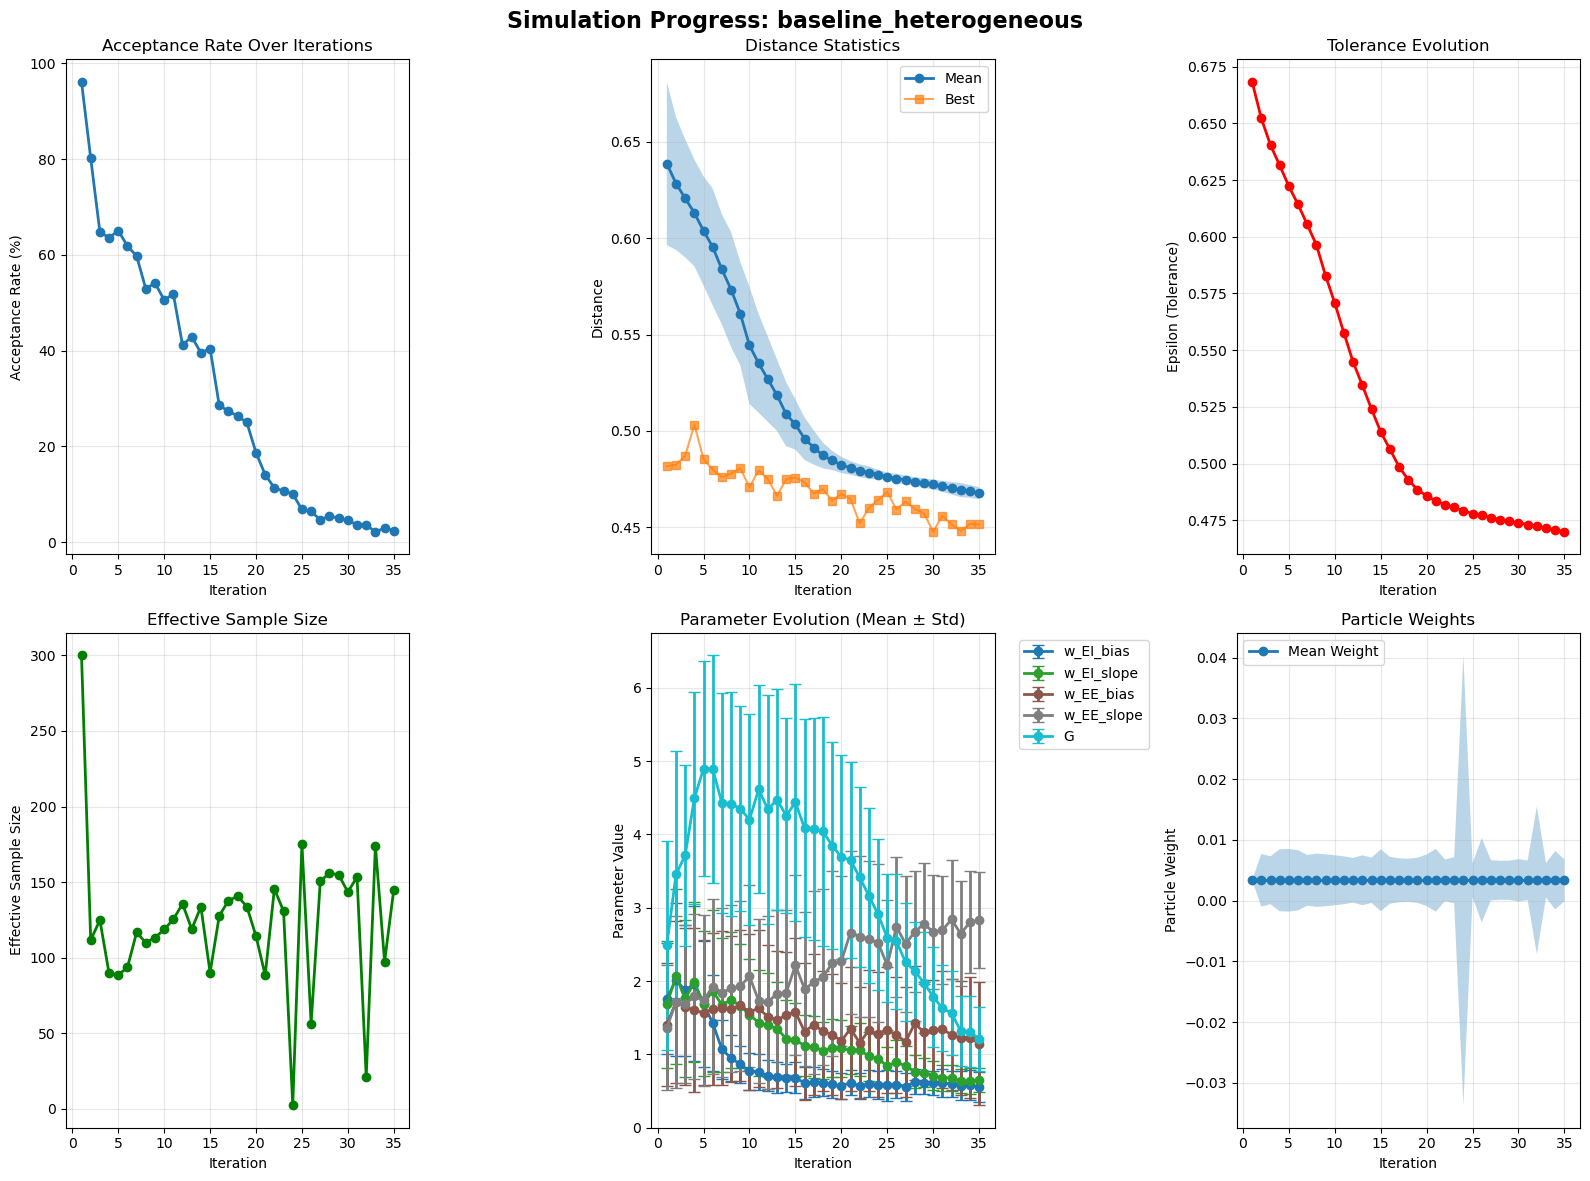


Creating progress plot for baseline_homogeneous...


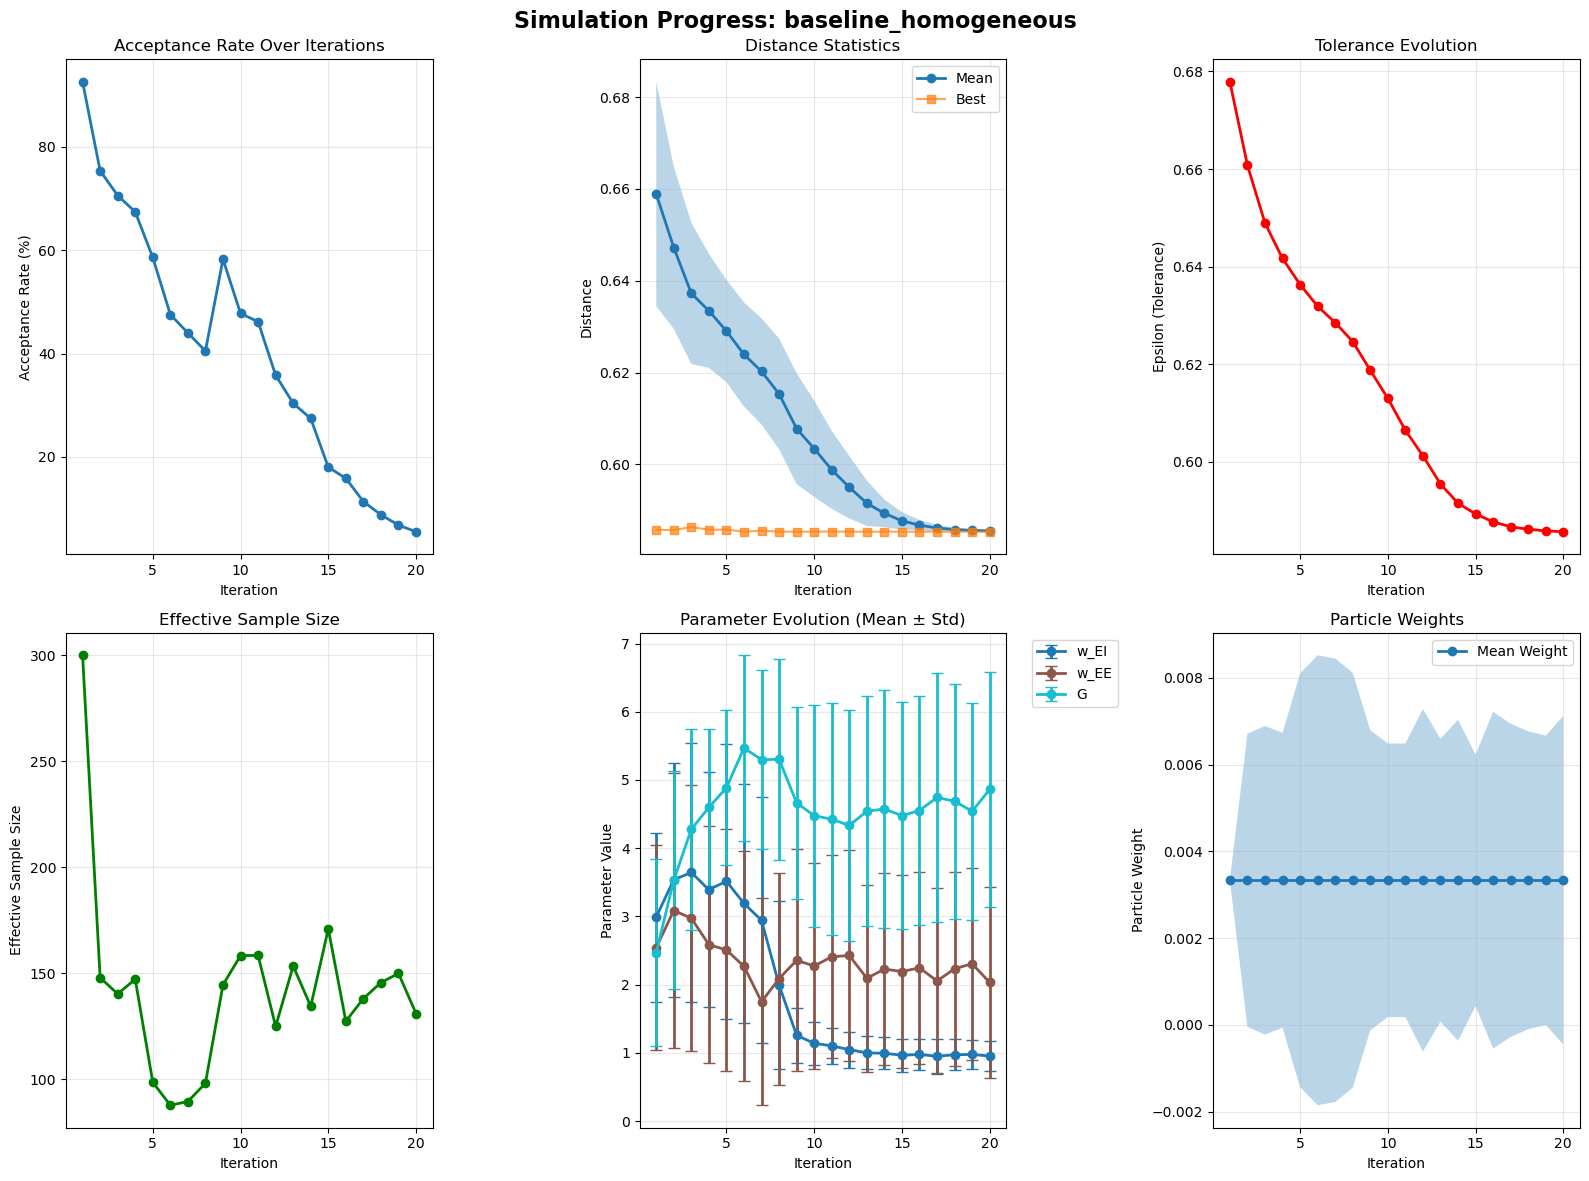


Creating progress plot for myelin_gaba...


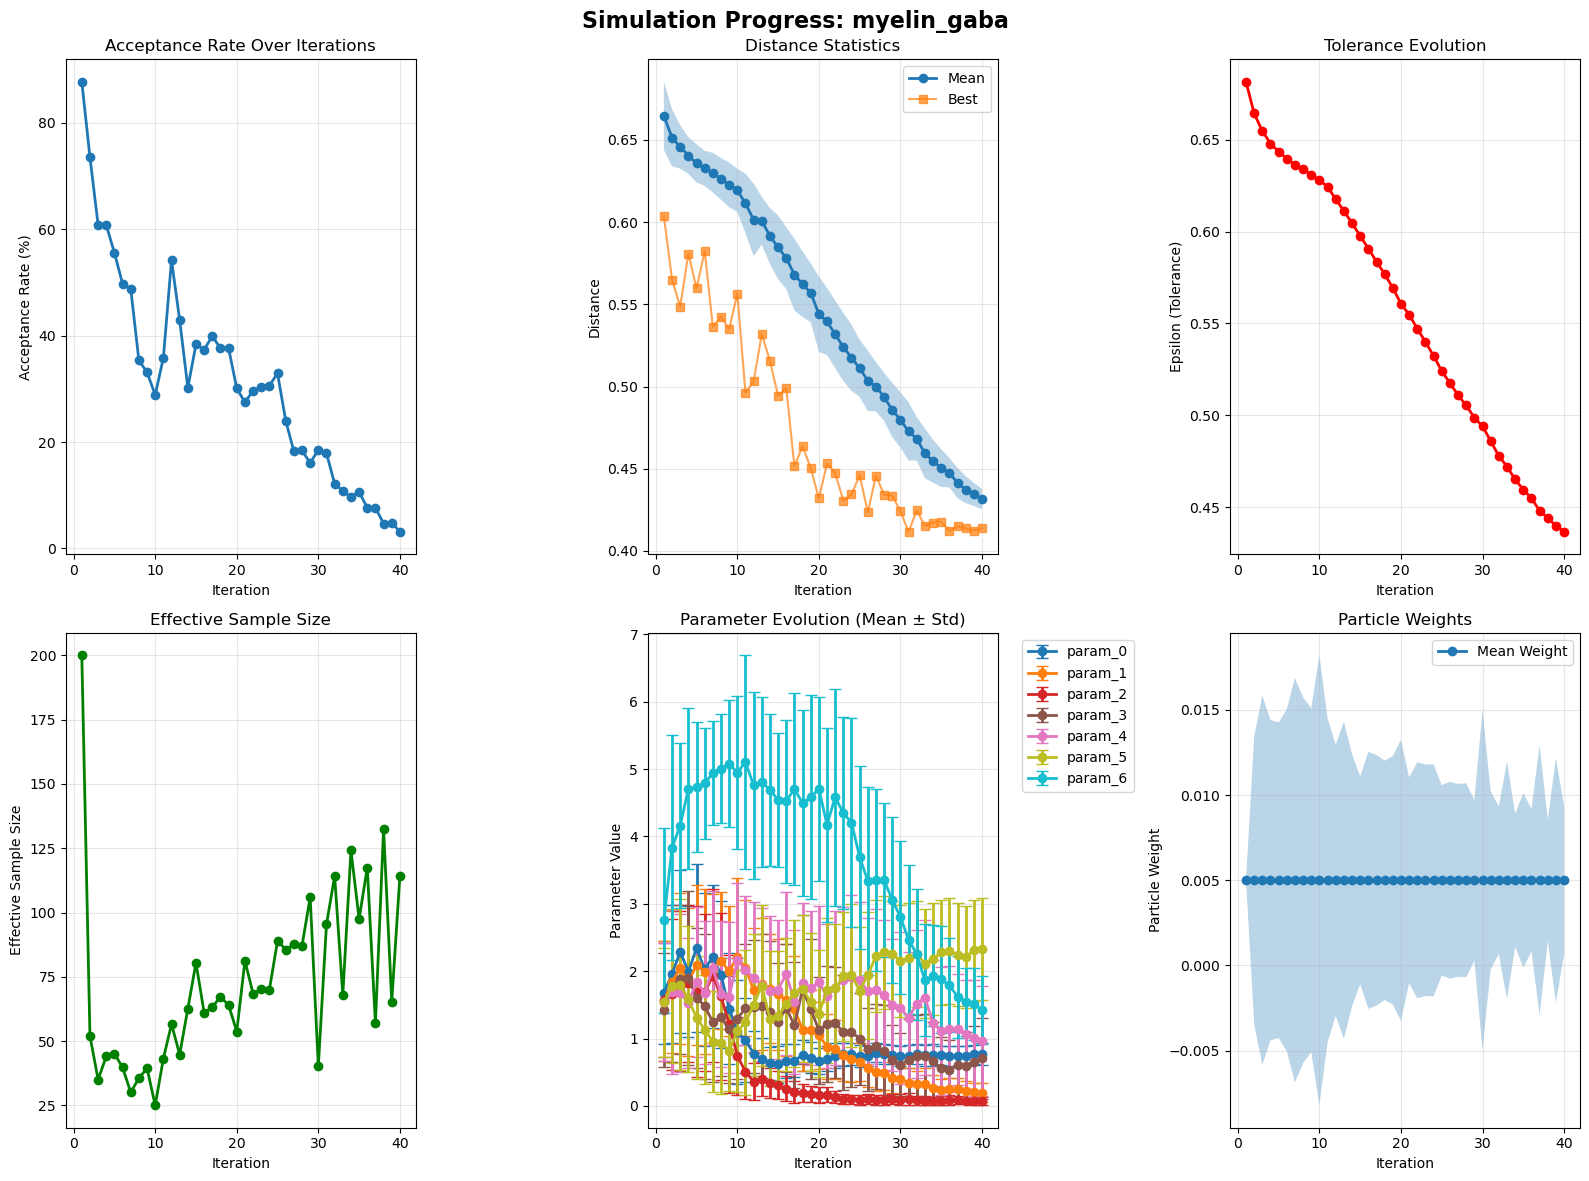


Creating progress plot for myelin_nmda...


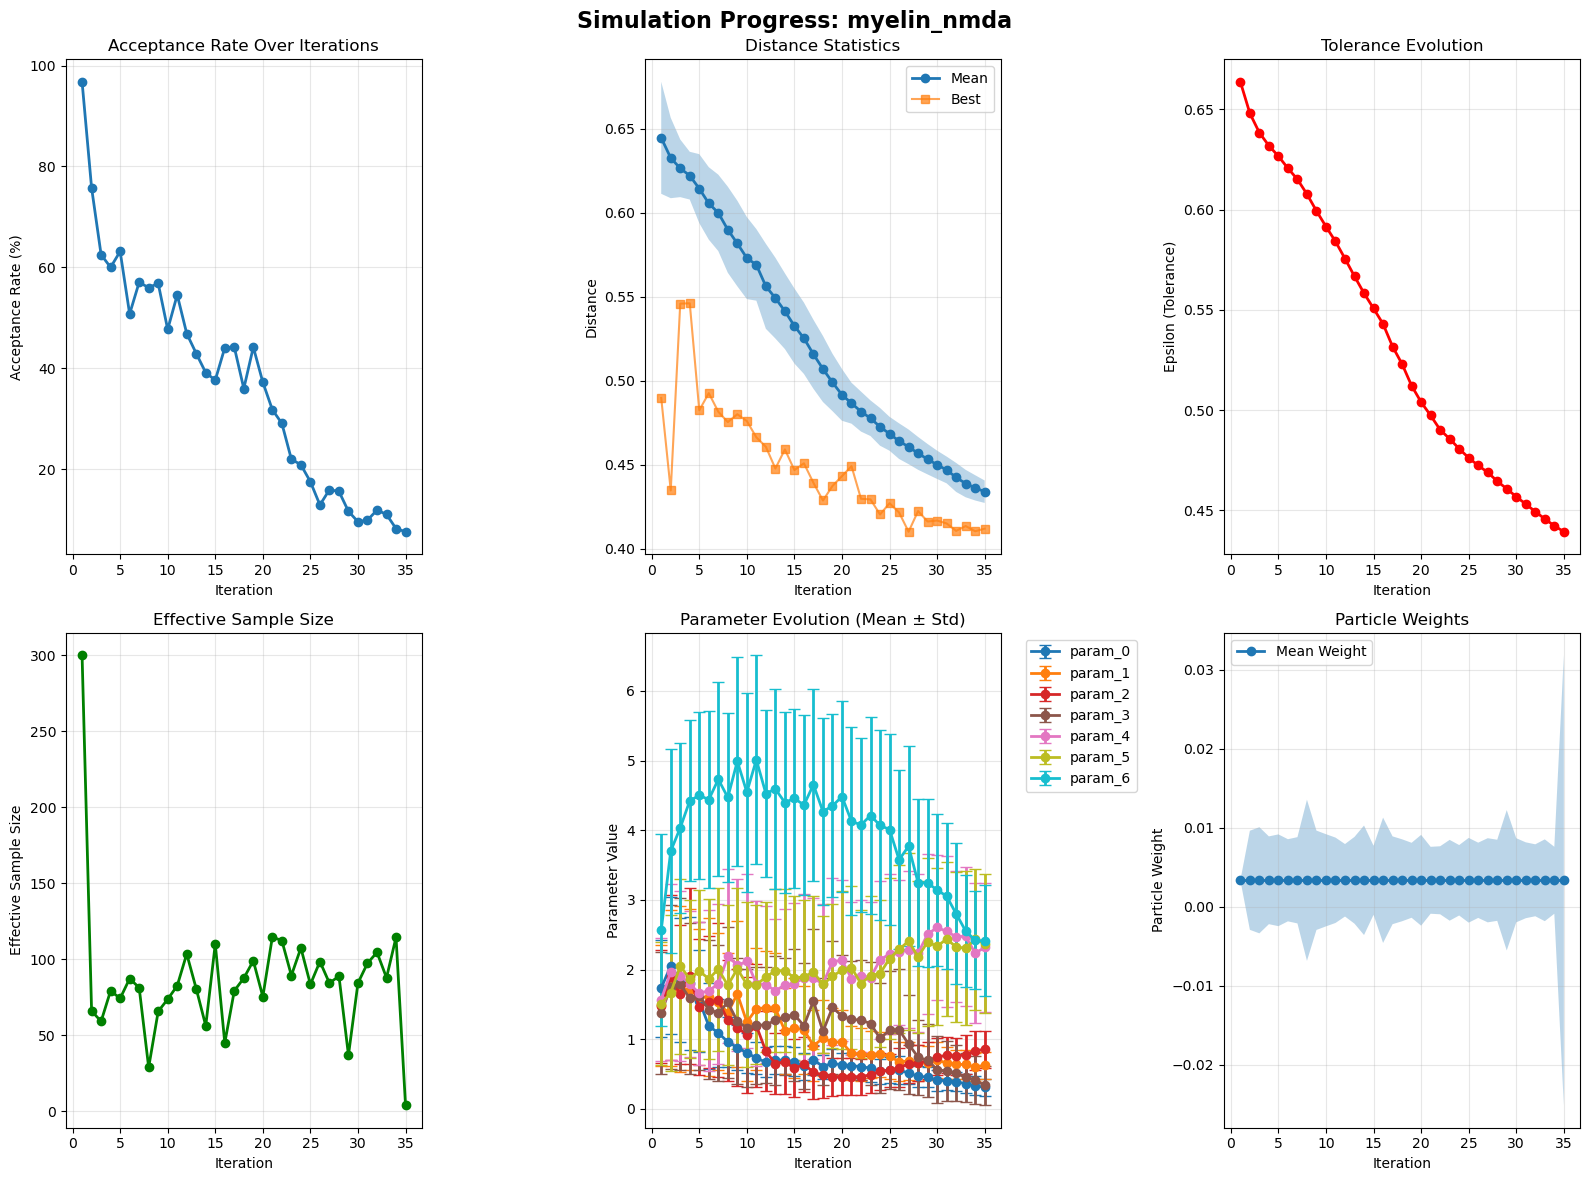


Creating progress plot for nmda_gaba...


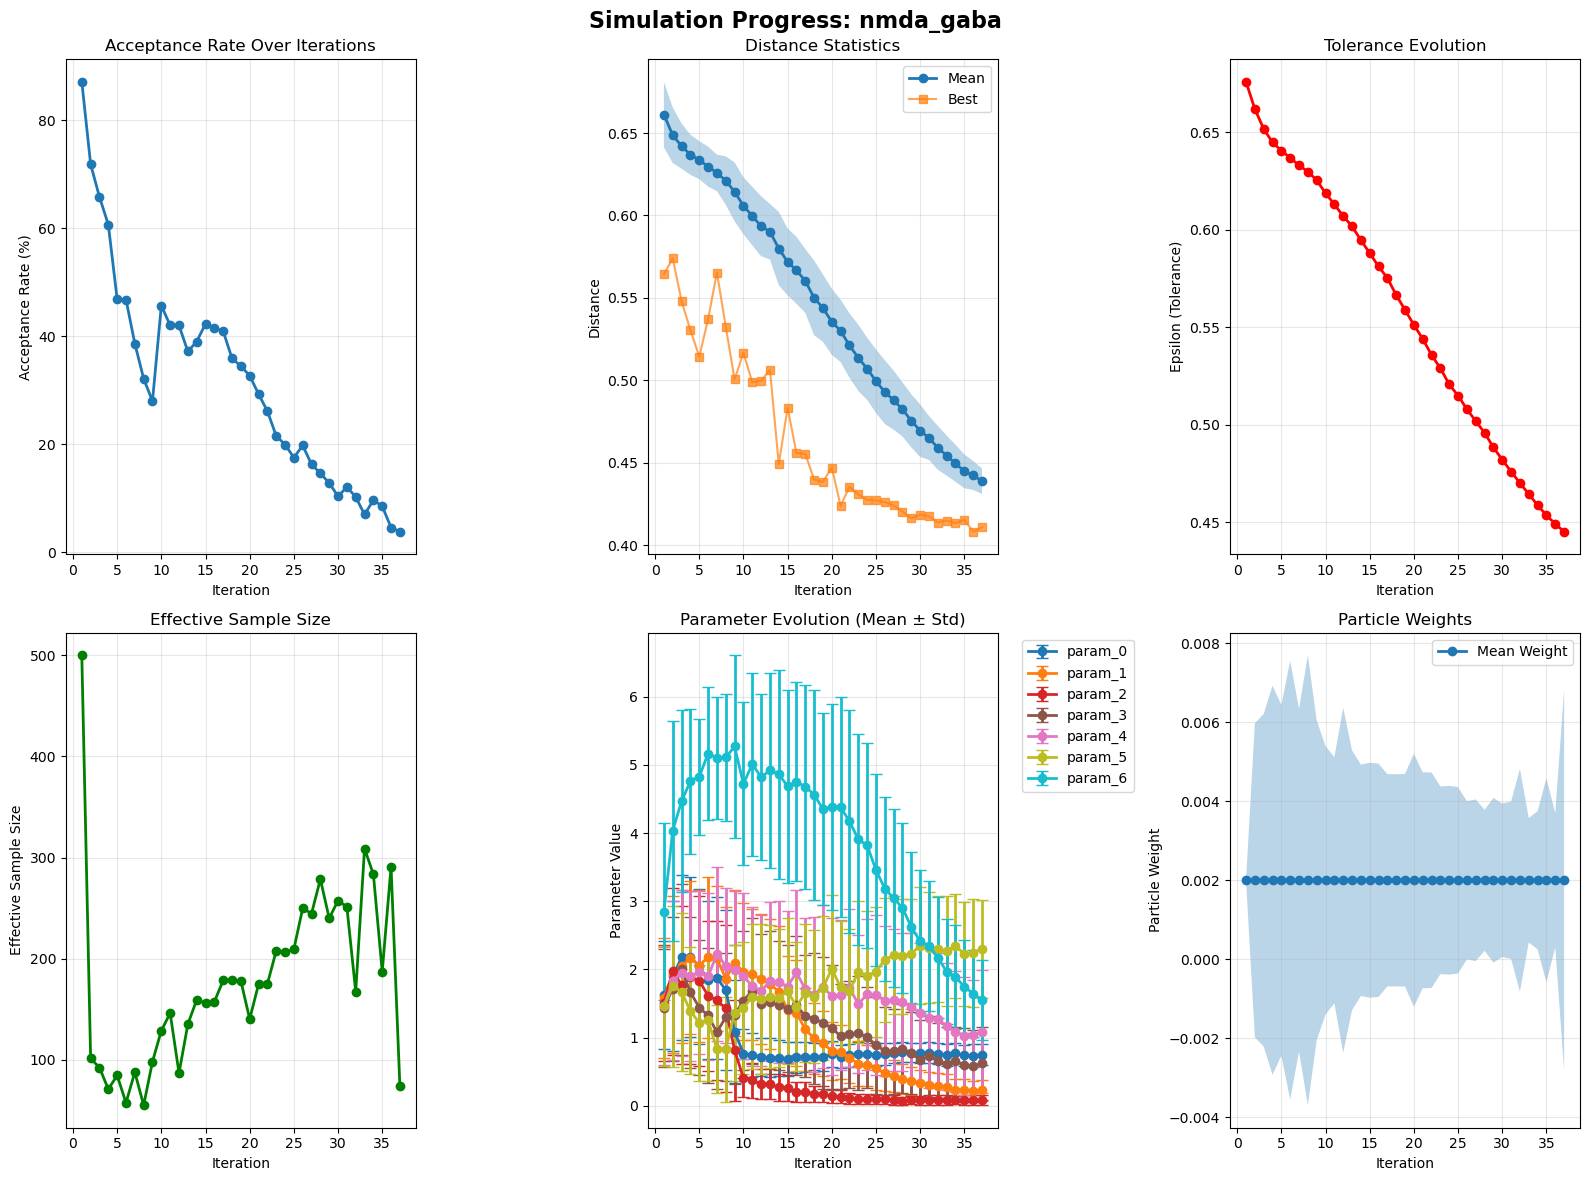


Creating progress plot for receptor_dopamine_avg...


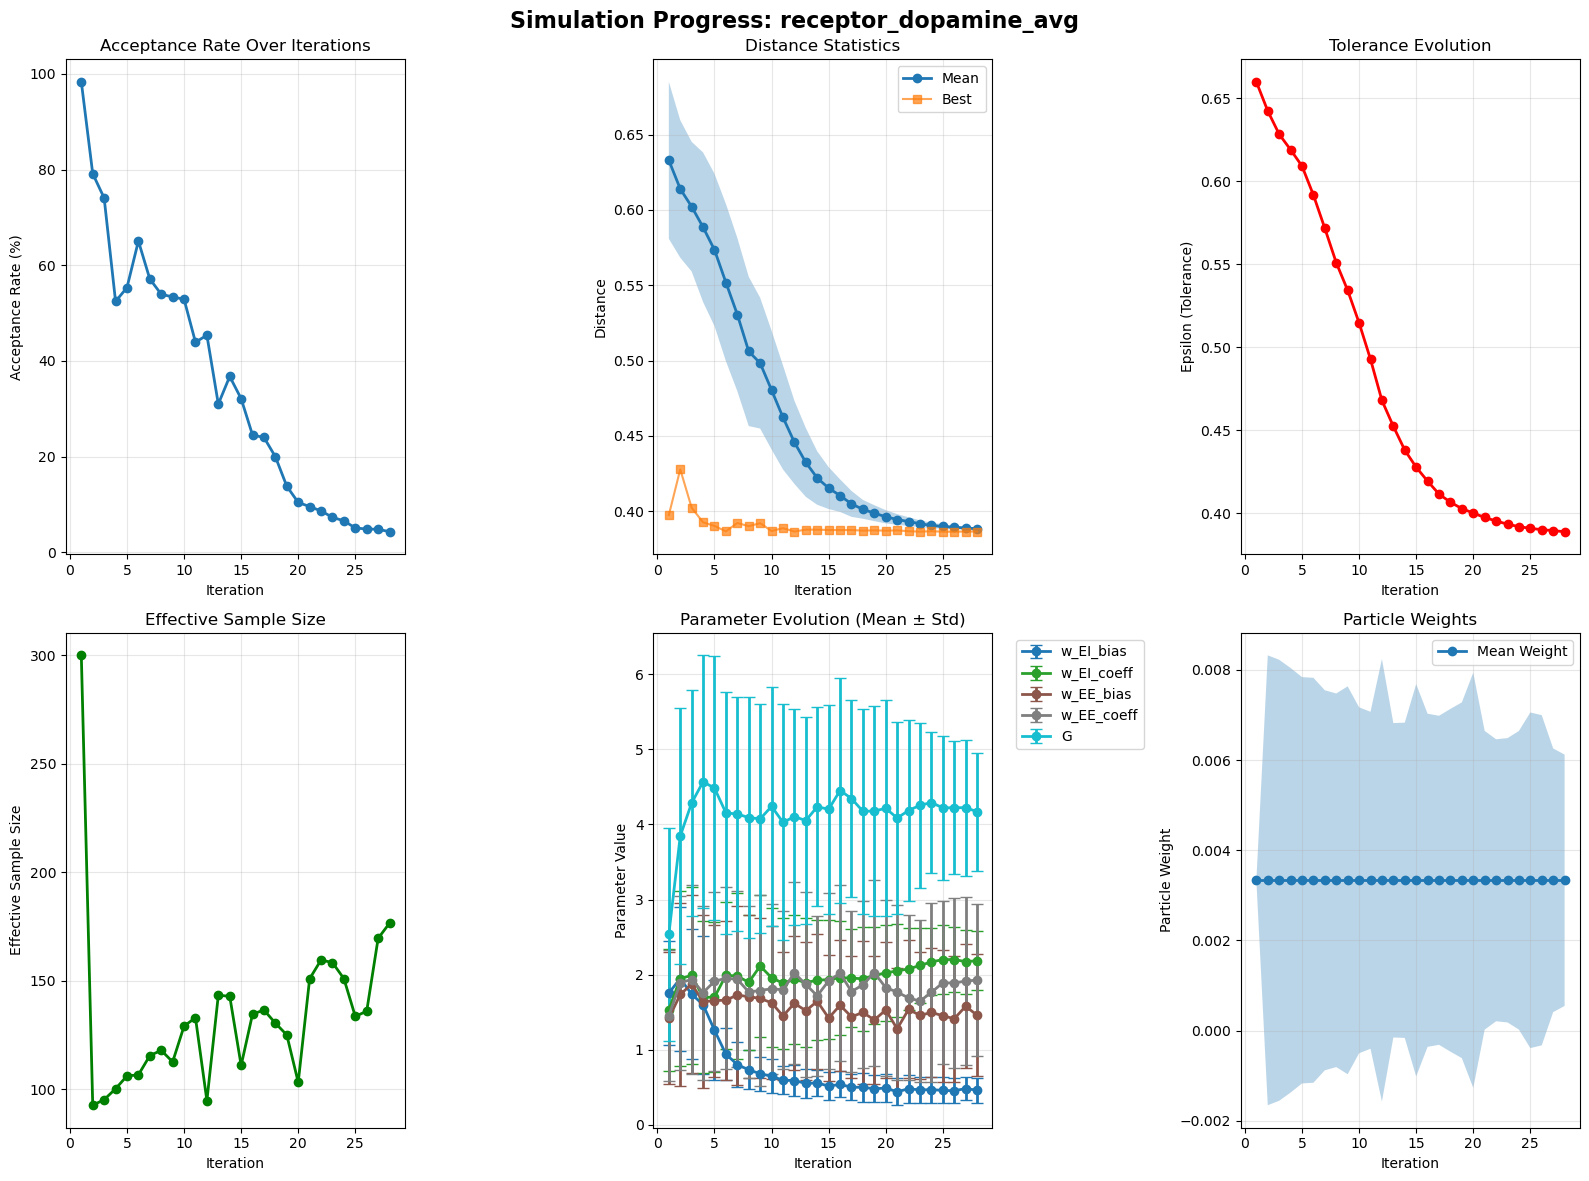


Creating progress plot for receptor_gaba_a_avg...


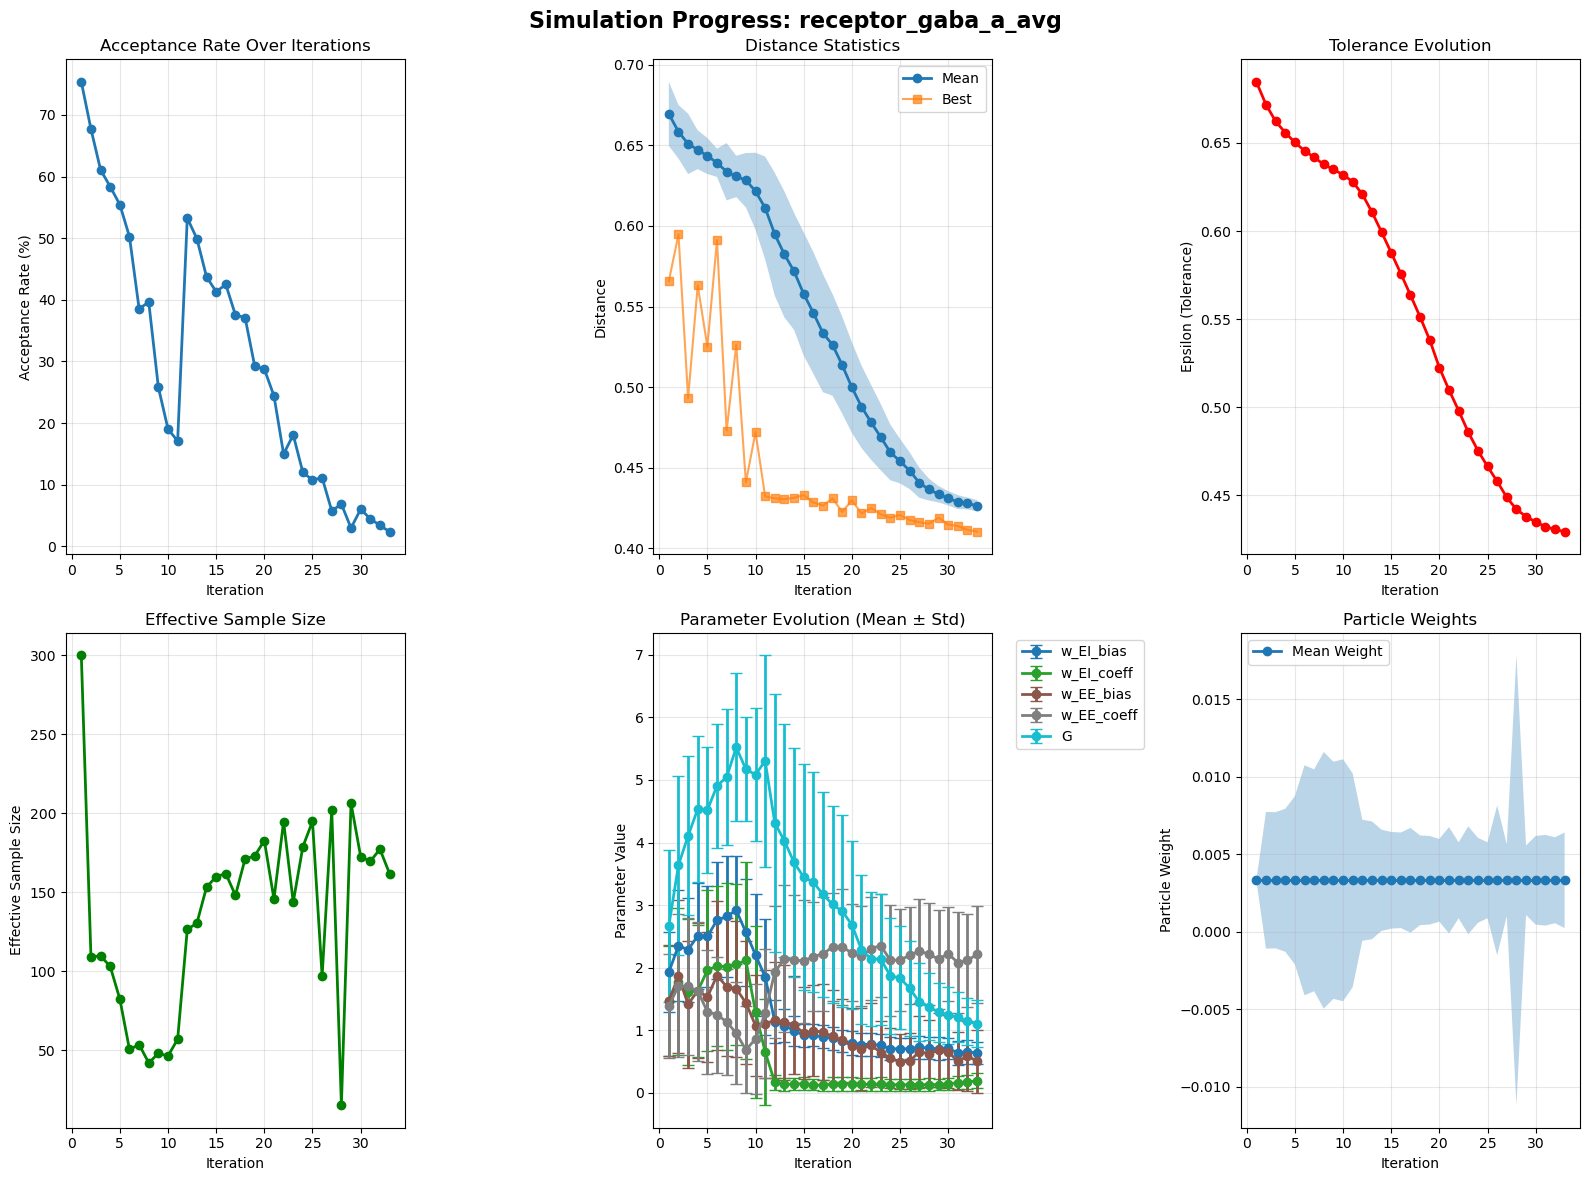


Creating progress plot for receptor_nmda_avg...


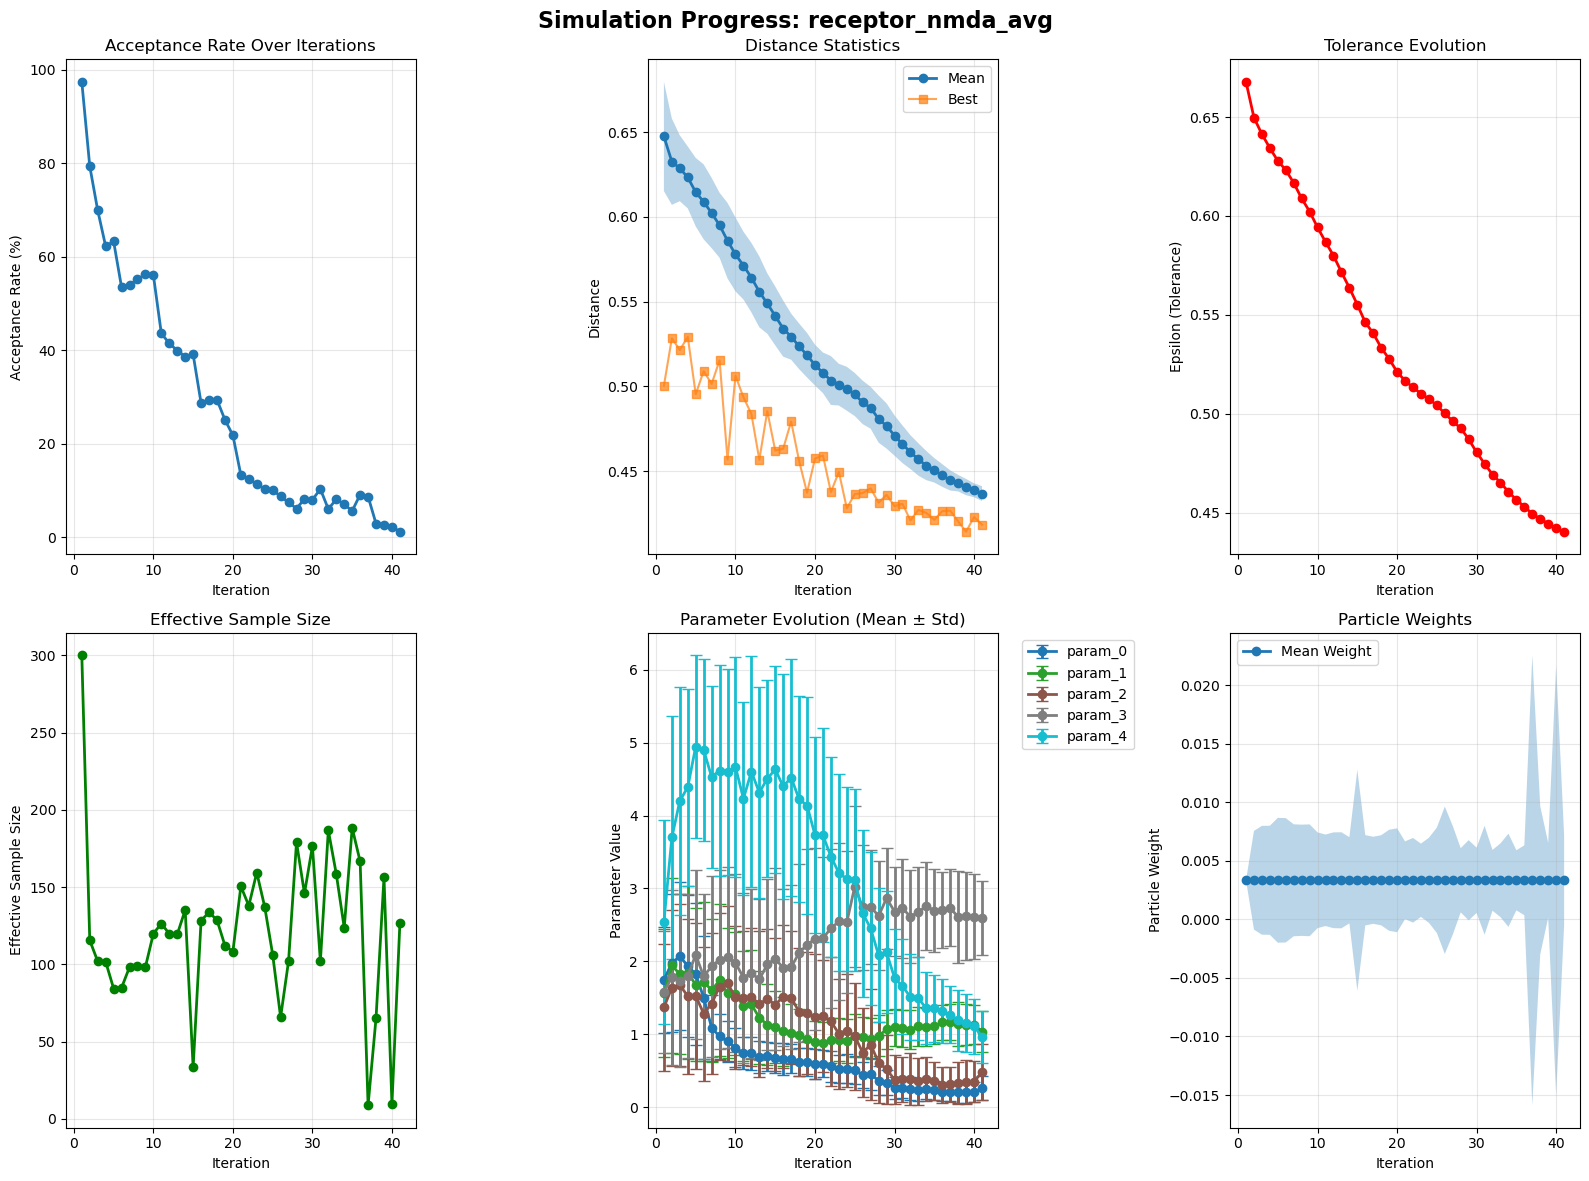


Creating progress plot for receptor_norepinephrine_avg...


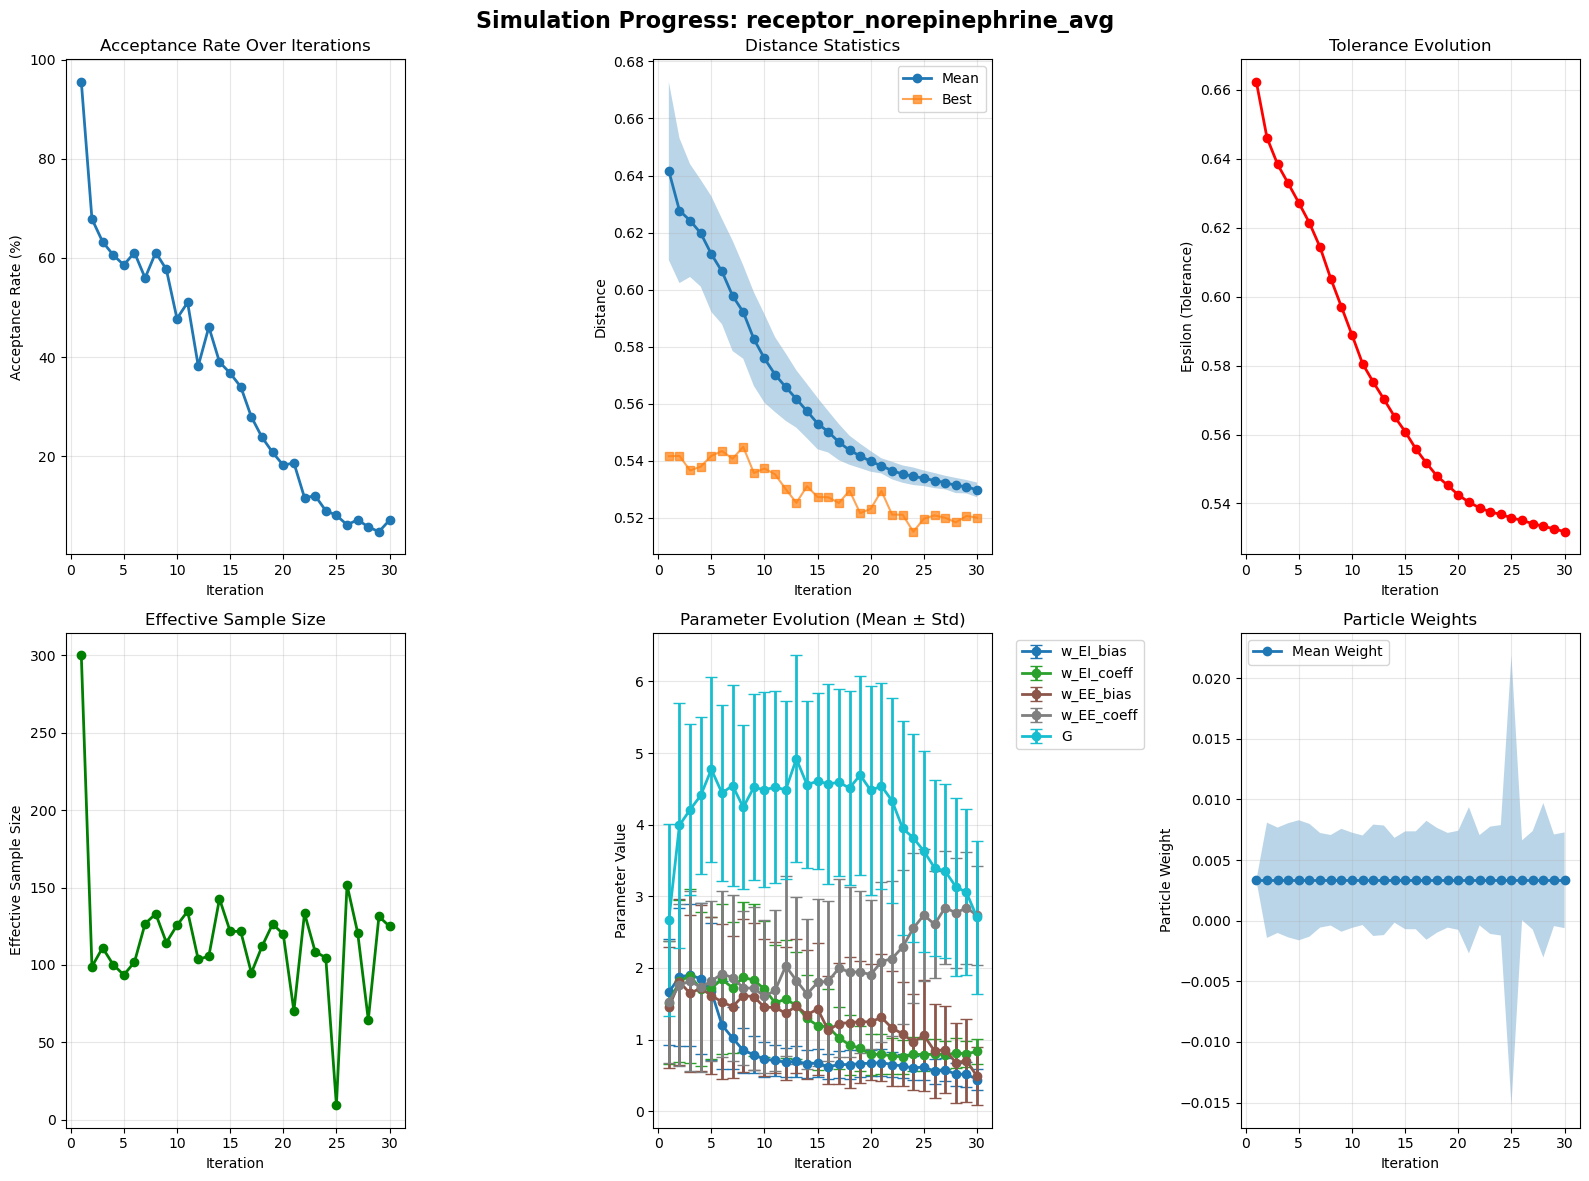

In [14]:
# Create individual simulation progress plots
print("\n" + "="*60)
print("CREATING INDIVIDUAL SIMULATION PLOTS")
print("="*60)

for sim_name in available_sims:
    print(f"\nCreating progress plot for {sim_name}...")
    fig = analyzer.plot_simulation_progress(sim_name, figsize=(16, 12))
    if fig is not None:
        plt.show()
        # You can save the figure if needed:
        # fig.savefig(f'{output_dir}/{sim_name}_progress.png', dpi=300, bbox_inches='tight')
    else:
        print(f"No plot could be created for {sim_name}")


In [15]:
# # Create detailed parameter evolution plots
# print("\n" + "="*60)
# print("CREATING PARAMETER EVOLUTION PLOTS")
# print("="*60)

# for sim_name in available_sims:
#     print(f"\nCreating parameter evolution plot for {sim_name}...")
#     fig = analyzer.plot_parameter_evolution(sim_name, figsize=(14, 10))
#     if fig is not None:
#         plt.show()
#         # You can save the figure if needed:
#         # fig.savefig(f'{output_dir}/{sim_name}_parameters.png', dpi=300, bbox_inches='tight')
#     else:
#         print(f"No parameter plot could be created for {sim_name}")



CREATING COMPARATIVE ANALYSIS
Creating comparative plot across all simulations...


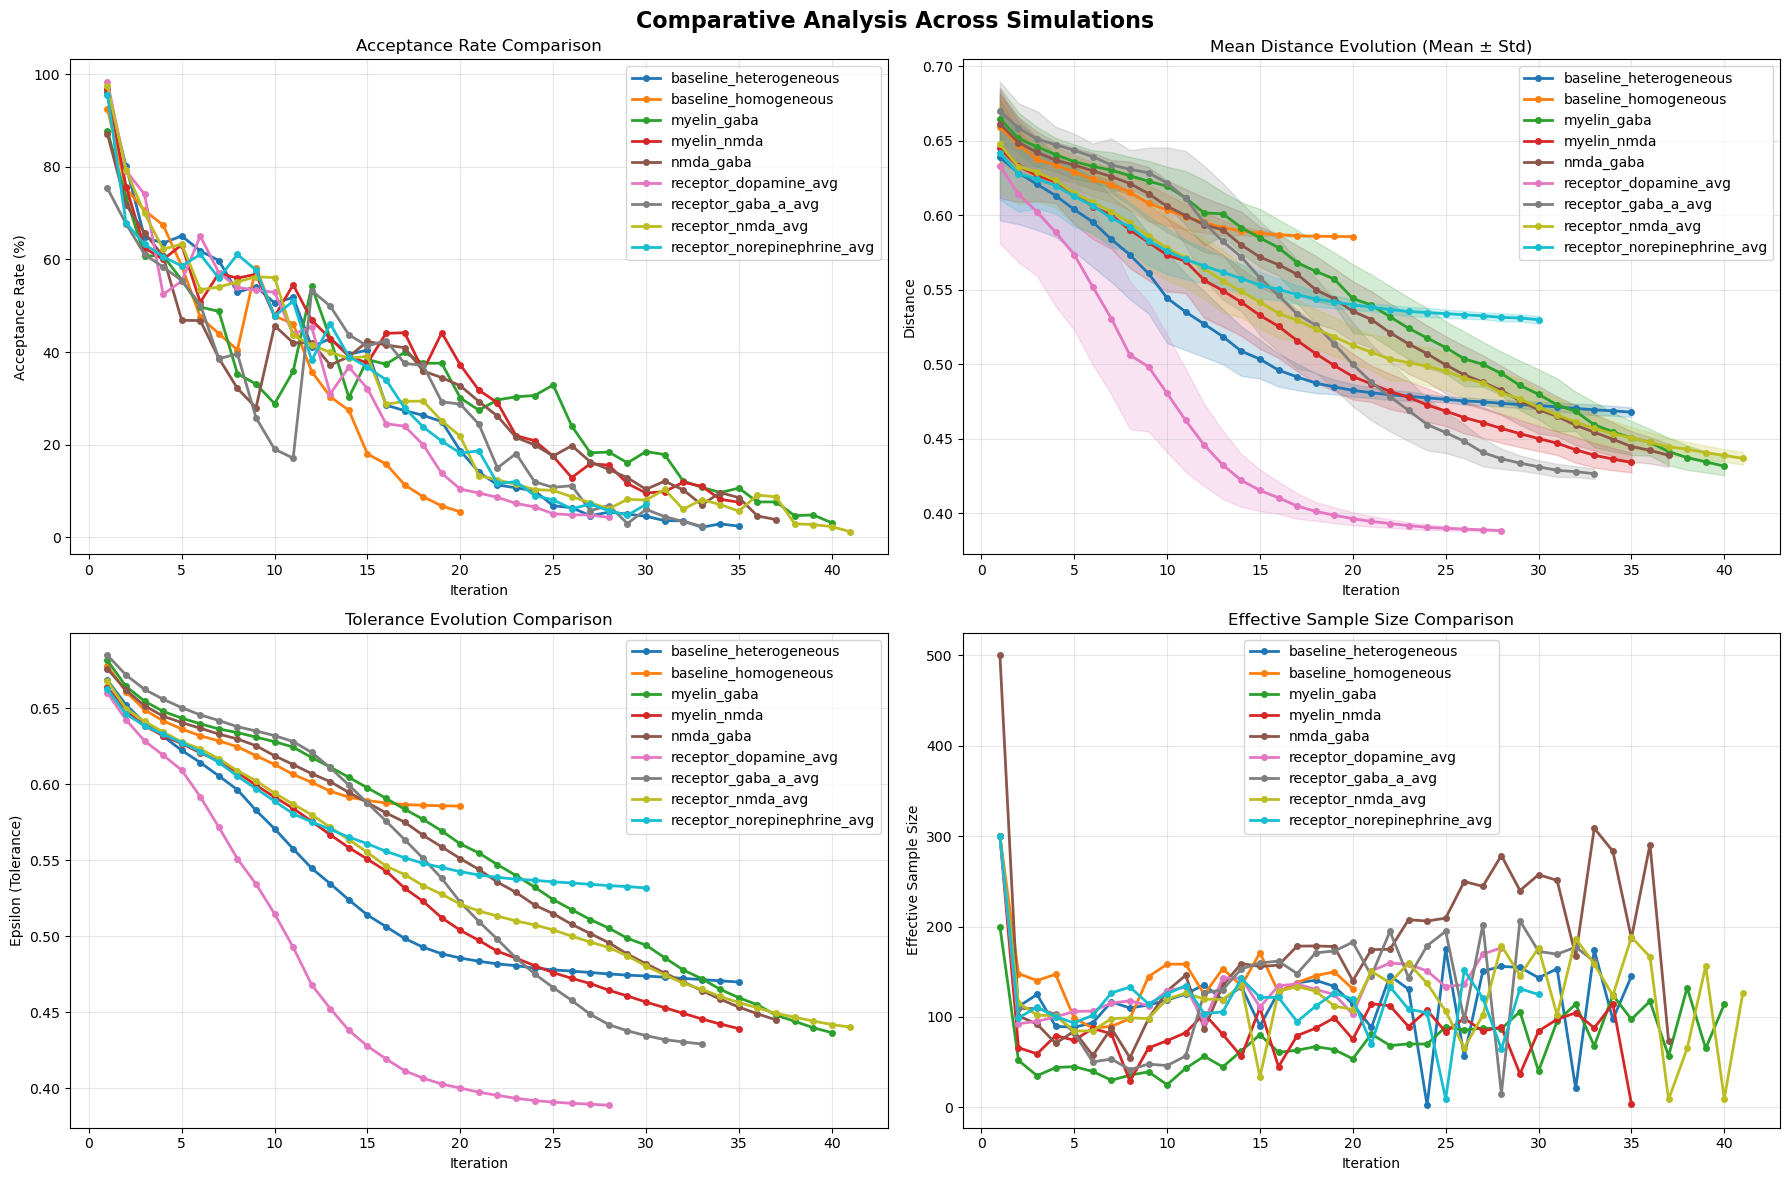

In [16]:
# Create comparative analysis across all simulations
if len(available_sims) > 1:
    print("\n" + "="*60)
    print("CREATING COMPARATIVE ANALYSIS")
    print("="*60)
    
    print("Creating comparative plot across all simulations...")
    fig = analyzer.plot_comparative_analysis(available_sims, figsize=(18, 12))
    if fig is not None:
        plt.show()
        # You can save the figure if needed:
        # fig.savefig(f'{output_dir}/comparative_analysis.png', dpi=300, bbox_inches='tight')
    else:
        print("No comparative plot could be created")
else:
    print("\nSkipping comparative analysis (need at least 2 simulations)")


In [17]:
# Save all plots and reports to a dedicated analysis folder
print("\n" + "="*60)
print("SAVING ALL PLOTS AND REPORTS")
print("="*60)

analysis_output_dir = f"{output_dir}/analysis_results"
analyzer.save_all_plots(analysis_output_dir, available_sims)

print(f"\nAll analysis results saved to: {analysis_output_dir}")
print("Files created:")
print("  • simulation_summary.csv - Summary statistics")
print("  • [simulation]_progress.png - Progress plots for each simulation")
print("  • [simulation]_parameters.png - Parameter evolution plots")
print("  • comparative_analysis.png - Cross-simulation comparison")



SAVING ALL PLOTS AND REPORTS
All plots and summary saved to: /Users/fdjim/Desktop/HBNM/HBNM/outputs/analysis_results

All analysis results saved to: /Users/fdjim/Desktop/HBNM/HBNM/outputs/analysis_results
Files created:
  • simulation_summary.csv - Summary statistics
  • [simulation]_progress.png - Progress plots for each simulation
  • [simulation]_parameters.png - Parameter evolution plots
  • comparative_analysis.png - Cross-simulation comparison


In [18]:
# Example: Access specific simulation data for custom analysis
print("\n" + "="*60)
print("EXAMPLE: ACCESSING SPECIFIC DATA")
print("="*60)

# Example of how to access specific simulation data
if 'baseline_myelin_nmda' in available_sims:
    sim_name = 'baseline_myelin_nmda'
    sim_data = all_simulation_data[sim_name]
    
    print(f"Example analysis for {sim_name}:")
    print(f"• Total iterations: {len(sim_data['iterations'])}")
    print(f"• Final iteration: {sim_data['iterations'][-1]}")
    print(f"• Parameter evolution:")
    
    # Get parameter statistics
    param_stats = analyzer.get_parameter_statistics(sim_name)
    final_params = param_stats['theta_means'][-1]  # Final iteration means
    
    for i, param_name in enumerate(param_stats['param_names']):
        print(f"  - {param_name}: {final_params[i]:.4f}")
    
    print(f"• Convergence metrics:")
    print(f"  - Final acceptance rate: {sim_data['acceptance_rate'][-1]:.1%}")
    print(f"  - Final effective sample size: {sim_data['ess'][-1]:.1f}")
    print(f"  - Best distance: {min([np.min(d) for d in sim_data['distances']]):.4f}")
else:
    print("baseline_myelin_nmda not available - showing available simulations instead:")
    for sim_name in available_sims:
        print(f"• {sim_name}: {len(all_simulation_data[sim_name]['iterations'])} iterations")



EXAMPLE: ACCESSING SPECIFIC DATA
baseline_myelin_nmda not available - showing available simulations instead:
• baseline_heterogeneous: 35 iterations
• baseline_homogeneous: 20 iterations
• myelin_gaba: 40 iterations
• myelin_nmda: 35 iterations
• nmda_gaba: 37 iterations
• receptor_dopamine_avg: 28 iterations
• receptor_gaba_a_avg: 33 iterations
• receptor_nmda_avg: 41 iterations
• receptor_norepinephrine_avg: 30 iterations


### **Explore Parameter Distributions**



### **Correlations with FC**

For each run, check the correlation with FC of the mean, median and best parameter combination